In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import time
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams["font.family"] = "serif"

import pickle
import json
import sklearn
from sklearn import model_selection

from tqdm import tqdm
from IPython.display import clear_output
import pickle

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype_int   = torch.int64
dtype_float = torch.float64

def tensor2set(states):
    return {tuple(state.tolist()) for state in states}
def set2tensor(states):
    return torch.tensor(list(states), dtype=dtype_int)
def tensor2list(states):
    return [tuple(state.tolist()) for state in states]
def list2tensor(states):
    return torch.tensor(states, dtype=dtype_int)

with open('data/kirills_data/qtm_cube4.pickle', 'rb') as handle:
    qtm_cube4 = pickle.load(handle)
all_moves = list2tensor(np.array(qtm_cube4["actions"]))
n_gens     = all_moves.size(0)
state_size = all_moves.size(1)

V0 = torch.arange(state_size, dtype=dtype_int)

# Define inverse moves mapping
inverse_moves = torch.tensor([1, 0, 3, 2, 5, 4, 7, 6, 9, 8, 11, 10, 13, 12, 15, 14, 17, 16], dtype=dtype_int)

def get_neighbors(states):
    return torch.gather(
        states.unsqueeze(1).expand(states.size(0), n_gens, state_size).to(device), 
        2, 
        all_moves.unsqueeze(0).expand(states.size(0), n_gens, state_size).to(device))

hash_vec = torch.randint(0, 1_000_000_000_000, (state_size,))
def state2hash(states):
    return torch.sum(hash_vec * (states//16), dim=1)

dummy_true = torch.tensor([True])
def get_unique_states(states, states_bad_hashed):
    idx = torch.arange(states.size(0), dtype=dtype_int, device=states.device)
    hashed = state2hash(states)
    mask1  = ~torch.isin(hashed, states_bad_hashed)
    hashed = hashed[mask1]
    hashed_sorted, idx_gus = torch.sort(hashed)
    mask2 = torch.concat((dummy_true, hashed_sorted[1:] - hashed_sorted[:-1] > 0))
    return states[mask1][idx_gus[mask2]], idx[mask1][idx_gus[mask2]]

# def do_random_step(states, last_moves):
#     # Создаем массив возможных ходов для каждого состояния, исключая обратные ходы
#     possible_moves = torch.ones((states.size(0), n_gens), dtype=torch.bool)
#     possible_moves[torch.arange(states.size(0)), inverse_moves[last_moves]] = False
#     # Генерация случайных индексов допустимых ходов
#     next_moves = torch.multinomial(possible_moves.float(), 1).squeeze()
#     # Применение ходов к состояниям и возврат новых состояний и последних ходов
#     return torch.gather(states, 1, all_moves[next_moves]), next_moves

def do_random_step(states):
    return torch.gather(states.to(device), 1, all_moves.to(device)[torch.randint(0, n_gens, (states.size(0),)).to(device)])

def get_tests(num_tests, R=1000): 
    states = V0.unsqueeze(0).repeat(num_tests, 1)
    last_move = torch.full((num_tests,), -1, dtype=dtype_int)  # initialize with invalid move index
    for _ in range(R):
        states, last_move = do_random_step(states, last_move)
    mask = torch.randint(0,1+1, (num_tests,)) > 0 # random parity
    if mask.sum() > 1:
        states[mask], last_move[mask] = do_random_step(states[mask], last_move[mask])
    return states

In [9]:
# разметка окрестности
def do_all_steps(states):
    return get_neighbors(states).flatten(end_dim=1).to(device)

def states2X(states):
    return torch.nn.functional.one_hot(states, num_classes=6).view(-1, state_size*6).to(torch.float).to(device)

V0 = torch.arange(6, dtype=dtype_int).repeat_interleave(state_size//6).to(device)

neighborhood_size = 5 

neighborhood_S = []
neighborhood_Y = []

states = set()
for j in tqdm(range(neighborhood_size)):
    if j == 0:
        g = V0.unsqueeze(0).to(device)
    else:
        g = do_all_steps(set2tensor(g_set).to(device))
    g_set = tensor2set(g)  - states
    states = states.union(g_set)
    
    ring = set2tensor(g_set).to(device)
    neighborhood_S.append(ring)
    neighborhood_Y.append(torch.full((ring.size(0),), j).to(device))
clear_output()

neighborhood_S = torch.concat(neighborhood_S).to(device)
neighborhood_X = states2X(neighborhood_S).to(device)
neighborhood_Y = torch.concat(neighborhood_Y).to(torch.float).to(device)

print(f"# states in V0 neighborhood {neighborhood_size} = {neighborhood_X.size(0)}")

hash_vec = torch.randint(0, 1_000_000_000_000, (state_size,)).to(device)
def get_unique_states_with_idx(states):
    hashed = torch.sum(hash_vec * states, dim=1).to(device)
    hashed_sorted, idx = torch.sort(hashed)
    mask = torch.concat((torch.tensor([True]).to(device), (hashed_sorted[1:] - hashed_sorted[:-1] > 0).to(device)))
    return states[idx][mask], idx.to(device), mask

# возможно не стоит делать шаг с unique
def generate_random_walks(k=100000, K_min=1, K_max=60, flag_unique=False):
    dataset = torch.zeros(((K_max - K_min + 1) * k, state_size), dtype=dtype_int).to(device)
    Ks = torch.arange(K_min, K_max+1).repeat_interleave(k).to(device)
    for (j, K) in enumerate(range(K_min, K_max+1)):
        states = V0.repeat(k, 1).to(device)
        for _ in range(K):
            states = do_random_step(states)
        dataset[j * k : (j+1) * k] = states
    
    if not flag_unique:
        return dataset, Ks
    else:
        dataset_unique, idx, mask = get_unique_states_with_idx(dataset)
#         dataset_unique, inverse_indices = torch.unique(dataset, dim=0, return_inverse=True)

#         Ks_unique = torch.full((len(dataset_unique),), K_max+1, dtype=dtype_int).to(device)
#         Ks_unique = Ks_unique.scatter_reduce_(0, inverse_indices, Ks, reduce="amin")
        Ks_unique = Ks[idx][mask]

        return dataset_unique, Ks_unique

def generate_xy_dataset(base_repeat=10, k=100_000, K_min=1, K_max=60, flag_unique=False):
    dataset, Ks = generate_random_walks(k=k, K_min=K_min, K_max=K_max, flag_unique=flag_unique)
    neighbors = get_neighbors(dataset).to(device)

    IDX = torch.arange(dataset.size(0)).to(device)
    idx_train, idx_val = sklearn.model_selection.train_test_split(IDX.cpu(), test_size=0.2, random_state=42)
    
    X = torch.nn.functional.one_hot(dataset, num_classes=6).view(-1, state_size*6).to(device)
#     X = torch.concatenate((X, torch.mean(states2X(neighbors.flatten(end_dim=1)).reshape((dataset.size(0), n_gens, 576)), dim=1)), dim=1)
#     X_train = X[idx_train].to(torch.float)
#     Y_train = Ks[idx_train].to(torch.float)
    X_train = torch.concat((X[idx_train].to(torch.float).to(device), neighborhood_X.repeat(base_repeat, 1).to(device)))
    Y_train = torch.concat((Ks[idx_train].to(torch.float).to(device), neighborhood_Y.repeat(base_repeat).to(device)))
    X_val   = X[idx_val].to(torch.float).to(device)
    Y_val   = Ks[idx_val].to(torch.float).to(device)
    
    return X_train, Y_train, X_val, Y_val

# states in V0 neighborhood 5 = 57199


In [10]:
X_train, Y_train, X_val, Y_val = generate_xy_dataset(base_repeat=1, k=1000, K_min=1, K_max=60, flag_unique=False)

## Model

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def count_parameters(model):
    """Count the trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout_rate=0.1):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

    def forward(self, x):
        residual = x
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out += residual
        out = self.relu(out)
        return out


class Pilgrim(nn.Module):
    def __init__(self, input_dim=576, hidden_dim1=3000, hidden_dim2=1000, num_residual_blocks=2, output_dim=1, dropout_rate=0.1):
        super(Pilgrim, self).__init__()
        self.hd1 = hidden_dim1
        self.hd2 = hidden_dim2
        self.nrd = num_residual_blocks
        
        self.input_layer = nn.Linear(input_dim, hidden_dim1)
        self.hidden_layer = nn.Linear(hidden_dim1, hidden_dim2)
        self.residual_blocks = nn.ModuleList([ResidualBlock(hidden_dim2, dropout_rate) for _ in range(num_residual_blocks)])
        self.output_layer = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(hidden_dim1)
        self.bn2 = nn.BatchNorm1d(hidden_dim2)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, z):
        # x = F.one_hot(z // 16, 6).float().view(-1, 96 * 6)
        x = self.relu(self.input_layer(z))
        x = self.bn1(x)
        x = self.dropout(x)
        x = self.relu(self.hidden_layer(x))
        x = self.bn2(x)
        x = self.dropout(x)
        for layer in self.residual_blocks:
            x = layer(x)
        x = self.output_layer(x)
        return x

In [4]:
def batch_process(model, data, device, batch_size):
    """
    Process data through a model in batches.

    :param data: Tensor of input data
    :param model: A PyTorch model with a forward method that accepts data
    :param device: Device to perform computations (e.g., 'cuda', 'cpu')
    :param batch_size: Number of samples per batch
    :return: Concatenated tensor of model outputs
    """
    model.eval()
    model.to(device)

    n_samples = data.shape[0]
    outputs = []

    # Process each batch
    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        batch = data[start:end].to(device)

        with torch.no_grad():
            batch_output = model(batch).flatten()
        
        # Store the output
        outputs.append(batch_output)

    # Concatenate all collected outputs
    final_output = torch.cat(outputs, dim=0)

    return final_output

## Trainer

In [5]:
import os
if not os.path.exists("weights"):
    os.makedirs("weights")

In [6]:
import torch
import numpy as np
import pandas as pd
import sklearn
import time

from IPython.display import clear_output
from ipywidgets import IntProgress
from IPython.display import display
import wandb


def get_dataloader(XY, batch_size):
    dataset = torch.utils.data.TensorDataset(*XY)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

class Meter:
    def __init__(self):
        self.metrics = {}
    
    def update(self, loss):
        self.metrics['loss'] += loss
    
    def init_metrics(self):
        self.metrics['loss'] = 0
        
    def get_metrics(self):
        return self.metrics


class Trainer:
    def __init__(self, 
                 net, 
                 num_epochs, 
                 device,
                 XY,
                 wandb_project_name="Pilgrim_v1",
                 verbose=2, batch_size=1024, 
                 wandb_flag=False, add_name="", 
                 version=0,
                 lr=0.001,
                 criterion = torch.nn.MSELoss(),
                 weights2load=False
                ):
        
        net_local = net 
        if weights2load: 
            net_local.load_state_dict(torch.load(weights2load))
            print("weights loaded")
        self.net = net_local.to(device)
        self.lr = lr
        self.device = device
        self.wandb_project_name = wandb_project_name
        self.XY = XY
        self.train_size = XY[0].shape[0]
        self.val_size = XY[2].shape[0]   
        self.num_epochs = num_epochs
        self.verbose = verbose
        self.batch_size = batch_size
        self.wandb_flag = wandb_flag
        self.add_name = add_name
        self.version = version
        self.epoch = 0
        self.outputs = []
        self.targets = []
        self.criterion = criterion
        self.optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.net.parameters()), lr=lr)
        self.best_loss = float('inf')
        self.phases = ['train', 'val']
        self.dataloaders = {
            'train': get_dataloader(XY[:2], batch_size),
            'val': get_dataloader(XY[2:], batch_size)
        }
        self.train_df_logs = pd.DataFrame()
        self.val_df_logs = pd.DataFrame()
    
    def upd_dataloaders(self):
        self.dataloaders = {
            'train': get_dataloader(self.XY[:2], self.batch_size),
            'val': get_dataloader(self.XY[2:], self.batch_size)
        }

    def upd_optimizer(self):
        self.optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.net.parameters()), lr=self.lr)

    def print_logs(self):
        clear_output(wait=True)
        
        y_pred = np.concatenate(self.outputs, axis=0)
        y_true = np.concatenate(self.targets, axis=0)  


        if self.wandb_flag:
            wandb_log = {
                "epoch": self.epoch,
                "lr": self.lr,
                "t_loss": self.train_df_logs.iloc[-1]['loss'],
                "v_loss": self.val_df_logs.iloc[-1]['loss'],
                "best_loss": self.best_loss
            };    
            wandb.log(wandb_log)
        if self.verbose > 0:
            print(f"v{self.version}")
            print(f"epoch: {self.train_df_logs.shape[0]}", end="\n\n")
            print(f"train:")
            print(f"    loss    {self.train_df_logs.iloc[-1]['loss']:.3f}")

            print(f"val:")
            print(f"    loss    {self.val_df_logs.iloc[-1]['loss']:.3f}")
        
    
    def _train_epoch(self, phase):    
        if phase == 'train': 
            self.net.train()
        else:  
            self.net.eval()

        meter = Meter()
        meter.init_metrics()
        
        # load bar
        if self.verbose > 1:
            print(f"\n{phase}:")
            if phase=='train': max_progress = self.train_size//self.batch_size
            else: max_progress = self.val_size//self.batch_size
            f = IntProgress(min=0, max=max_progress)
            display(f)
                
        self.outputs = []
        self.targets = []
        for i, (data, target) in enumerate(self.dataloaders[phase]):
            data = data.to(self.device)
            target = target.to(self.device)
            output = self.net(data).flatten()    
            loss = self.criterion(output, target)
                        
            if phase == 'train':
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
            else:
                self.outputs.append(output.detach().to('cpu').numpy())
                self.targets.append(target.detach().to('cpu').numpy())
                
            meter.update(loss.item())
            if self.verbose > 1: f.value += 1
                  
        metrics = meter.get_metrics()
        metrics = {k:v/(i+1) for k, v in metrics.items()}
        df_logs = pd.DataFrame([metrics])
        
        if phase == 'train':
            self.train_df_logs = pd.concat([self.train_df_logs, df_logs], axis=0)
        else:
            self.val_df_logs = pd.concat([self.val_df_logs, df_logs], axis=0)   
        return loss
    
    
    def run(self):
        print("start")
        
        if self.wandb_flag and self.epoch==0:
            wandb.init(
                project=self.wandb_project_name, 
                name=f"{self.add_name}",
                tags=[self.add_name],
                config={
                    "v" : self.version,
                    "batch_size" : self.batch_size,
                    "hd1" : self.net.hd1,
                    "hd2" : self.net.hd2,
                    "nrd" : self.net.nrd,
                    "params" : count_parameters(self.net)
                })
            print("wandb ok")
        
        for epoch in range(self.num_epochs):
            self.epoch += 1
            t1 = time.time()
            self._train_epoch(phase='train')
            with torch.no_grad():
                val_loss = self._train_epoch(phase='val')
            
            if val_loss < self.best_loss:
                self.best_loss = val_loss
                torch.save(self.net.state_dict(), f"weights/{self.add_name}_{self.version}.pth")
            t2 = time.time()
        
            self.print_logs()
            if self.verbose > 0:
                print(f"\nremaining time: {(t2-t1)*(self.num_epochs-epoch)/60:.2f} min")
                print(f"time/epoch: {(t2-t1)/60:.2f} min")
#         if self.wandb_flag: wandb.finish()
        print("end")

In [7]:
def train_model(hd1, hd2, nrd, batch_size=4096, version=0, K_max=60, weights2load=None, lr_scale=1, wandb_flag=False, epochs=10):
    model = Pilgrim(
        hidden_dim1 = hd1, 
        hidden_dim2 = hd2, 
        num_residual_blocks = nrd, 
        dropout_rate=0.1
    )
    print("model is ready:", count_parameters(model))
    
    XY = generate_xy_dataset(base_repeat=1, k=1_000, flag_unique=True)
    if weights2load:
        trainer = Trainer(
            net=model, num_epochs=1,
            batch_size=2048,
            verbose=2, wandb_flag=wandb_flag, add_name=f"IV_{hd1}_{hd2}x{nrd}_K{K_max}", version=version,
            lr=0.001, device=device,
            weights2load=f"{weights2load}",
            XY = XY,
            wandb_project_name="Pilgrim_v3"
        )
    else:
        trainer = Trainer(
            net=model, num_epochs=1,
            batch_size=2048,
            verbose=2, wandb_flag=wandb_flag, add_name=f"IV_{hd1}_{hd2}x{nrd}_K{K_max}", version=version,
            lr=0.001, device=device,
            XY = XY,
            wandb_project_name="Pilgrim_v3"
        )
    print("trainer is ready")
    
    for (lr, num_gens, num_reps) in zip(
        [0.001],
        [1],
        [epochs]
    ):
        trainer.lr = lr * lr_scale
        trainer.upd_optimizer()
        for _ in range(num_gens):
            trainer.XY = generate_xy_dataset(base_repeat=1, k=10_000, flag_unique=True, K_min=1, K_max=K_max) 
            trainer.batch_size = batch_size
            trainer.num_epochs = num_reps
            trainer.upd_dataloaders()
            trainer.run()
    
    wandb.finish()

## Train

In [16]:
from sklearn import model_selection
train_model(3000, 1000, 2, version=3)

model is ready: 8753001
trainer is ready
start

train:


IntProgress(value=0, max=25)

KeyboardInterrupt: 

## Load Models

In [8]:
M0 = Pilgrim(); M0.load_state_dict(torch.load(f"data/kirills_data/RC4_V_DC_8M_0.pth", weights_only=False));
M1 = Pilgrim(); M1.load_state_dict(torch.load(f"data/kirills_data/RC4_V_DC_8M_1.pth", weights_only=False));
M2 = Pilgrim(); M2.load_state_dict(torch.load(f"data/kirills_data/RC4_V_DC_8M_2.pth", weights_only=False));

In [9]:
def pred_d_ensemble(states):
    return torch.median(torch.concat((
        batch_process(M0, states, device, 4096).cpu().unsqueeze(0),
        batch_process(M1, states, device, 4096).cpu().unsqueeze(0),
        batch_process(M2, states, device, 4096).cpu().unsqueeze(0)
    ), dim=0), dim=0)[0]

In [10]:
def upd_device(mode):
    global all_moves, hash_vec, dummy_true, V0, pred_d
    if mode == "gpu":
        all_moves = all_moves.to(device)
        hash_vec = hash_vec.to(device)
        dummy_true = dummy_true.to(device)
        V0 = V0.to(device)
        def pred_d(states):
            pred_v = pred_d_ensemble(states)
            mask_finish = (states==V0).all(dim=1)
            pred_v[mask_finish] = 0
            return torch.clip(pred_v, 0, torch.inf), None, mask_finish.any()
    elif mode == "cpu":
        all_moves = all_moves.cpu()
        hash_vec = hash_vec.cpu()
        dummy_true = dummy_true.cpu()
        V0 = V0.cpu()
        def pred_d(states):
            pred_v = pred_d_ensemble(states)
            mask_finish = (states==V0).all(dim=1)
            pred_v[mask_finish] = 0
            return torch.clip(pred_v, 0, torch.inf).cpu(), None, mask_finish.any().cpu()
    else:
        print("Wrong device mode.")

## Beam Search

In [11]:
# value
def do_greedy_step(states, value_last, states_bad_hashed, B=1000, alpha=None):
    # найти соседей
    idx0 = torch.arange(states.size(0), device=device).repeat_interleave(n_gens)
    moves = torch.arange(n_gens, device=device).repeat(states.size(0))
    neighbors = get_neighbors(states).flatten(end_dim=1)
    # отфильтровать соседей
    neighbors, idx1 = get_unique_states(neighbors, states_bad_hashed)
    # посчитать value на соседях
    value = pred_d(neighbors)[0]
    # отсортировать и обрубить
    idx2 = torch.argsort(value)[:B]
    return neighbors[idx2], value[idx2], moves[idx1[idx2]], idx0[idx1[idx2]]

In [12]:
def check_stagnation(states_log):
    return torch.isin(torch.concat(states_log[2:]), torch.concat(states_log[:2])).all().item()

def get_solution(state, B=2**12, num_steps=500, num_attempts=10):
    global states_bad_hashed
    states_bad_hashed = torch.tensor([], dtype=dtype_int, device=device)
    for J in range(num_attempts):
        # Инициализация начального состояния и деревьев ходов и индексов
        states = state.unsqueeze(0).clone()
        tree_move = torch.zeros((num_steps, B), dtype=dtype_int)
        tree_idx  = torch.zeros((num_steps, B), dtype=dtype_int)
        y_pred = torch.tensor([0], dtype=dtype_float, device=device)
        # Лог для хранения состояний на последних 4 шагах
        states_hash_log   = [0] * 4
        # Основной цикл решения
        for j in range(num_steps):
            # print(f"run      {counter:3d}")
            # print(f"attempt  {J:3d}/{num_attempts:3d}")
            # print(f"step     {j:3d}/{num_steps:3d}")
            # print(f"\n# banned: {len(states_bad_hashed)}")
            clear_output(wait=True)
            # Выполнение жадного шага
            states, y_pred, moves, idx = do_greedy_step(states, y_pred, states_bad_hashed, B)
            states_hash_log[j % 4] = state2hash(states)

            leaves_num = states.size(0)
            # Обновление дерева ходов и индексов
            tree_move[j, :leaves_num] = moves
            tree_idx[j, :leaves_num] = idx

            # Проверка, достигли ли состояния V0
            if ((states//16) == (V0//16)).all(dim=1).any():
                break
            # Проверка на стагнацию или достижение максимального количества шагов
            elif (j > 3 and check_stagnation(states_hash_log)):
                # Обновление списка плохих состояний
                states_bad_hashed = torch.concat((states_bad_hashed, torch.concat(states_hash_log)))
                states_bad_hashed = torch.unique(states_bad_hashed)
                break

        # Проверка, достигли ли состояния V0
        if ((states//16) == (V0//16)).all(dim=1).any():
            break
    if J+1 == num_attempts:
        return None, J
                
    # Переворот дерева для восстановления пути
    tree_idx, tree_move = tree_idx[:j+1].flip((0,)), tree_move[:j+1].flip((0,))

    # Нахождение позиции состояния V0
    V0_pos = torch.nonzero(((states//16) == (V0//16)).all(dim=1), as_tuple=True)[0].item()

    # Построение пути в обратном порядке
    path = [tree_idx[0, V0_pos].item()]
    for k in range(1, j+1):
        path.append(tree_idx[k, path[-1]].item())

    # Восстановление последовательности ходов
    moves_seq = torch.tensor([
        tree_move[k, path[k-1]] if k > 0 else tree_move[k, V0_pos] for k in range(j+1)
    ], dtype=dtype_int)

    # Возврат последовательности ходов в правильном порядке
    return moves_seq.flip((0,)), J
    
def apply_moves(state, moves):
    V = state.clone()
    for move in moves:
        V = V[all_moves[move]]
    return V

def generate_path(state, moves):
    L = len(moves)
    path = torch.zeros((L+1, state_size), dtype=dtype_int)
    V = state.clone()
    path[0] = V
    for (j, move) in enumerate(moves):
        V = V[all_moves[move]]
        path[j+1] = V
    return path

def check_solution(state):
    return ((state//16).cpu() == (V0//16).cpu()).all().item()

In [13]:
upd_device('gpu')

In [14]:
class Pilgrim(nn.Module):
    def __init__(self, input_dim=576, hidden_dim1=3000, hidden_dim2=1000, num_residual_blocks=2, output_dim=1, dropout_rate=0.1):
        super(Pilgrim, self).__init__()
        self.hd1 = hidden_dim1
        self.hd2 = hidden_dim2
        self.nrd = num_residual_blocks
        
        self.input_layer = nn.Linear(input_dim, hidden_dim1)
        self.hidden_layer = nn.Linear(hidden_dim1, hidden_dim2)
        self.residual_blocks = nn.ModuleList([ResidualBlock(hidden_dim2, dropout_rate) for _ in range(num_residual_blocks)])
        self.output_layer = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(hidden_dim1)
        self.bn2 = nn.BatchNorm1d(hidden_dim2)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, z):
        x = F.one_hot(z // 16, 6).float().view(-1, 96 * 6)
        x = self.relu(self.input_layer(x))
        x = self.bn1(x)
        x = self.dropout(x)
        x = self.relu(self.hidden_layer(x))
        x = self.bn2(x)
        x = self.dropout(x)
        for layer in self.residual_blocks:
            x = layer(x)
        x = self.output_layer(x)
        return x

In [15]:
def do_random_step(states):
    return torch.gather(states.to(device), 1, all_moves.to(device)[torch.randint(0, n_gens, (states.size(0),)).to(device)])

V0 = torch.arange(state_size, dtype=dtype_int).to(device)

R_range = 30
tests_num = 2
beam_width = 1000
solved_nums = []
counter  = 0
for R in range(1,R_range):
    print('R=', R)
    solved_num = 0
    for num_test in range(tests_num):
        state_test = V0.unsqueeze(0).to(device)
        for _ in range(R):
            state_test = do_random_step(state_test)
        state_test = state_test[0].float()
        moves, J = get_solution(state_test, B=beam_width)
        if moves is not None:
            solved_num += 1
    solved_nums.append(solved_num)  

RuntimeError: mat1 and mat2 shapes cannot be multiplied (18x96 and 576x3000)

In [16]:
V0

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95], device='cuda:0')

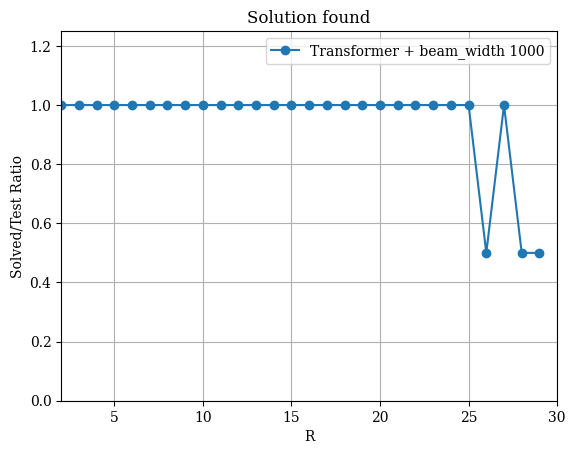

<module 'matplotlib.pyplot' from 'c:\\Users\\zamko\\Documents\\graphs\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [18]:

# Assuming solved_nums and tests_num are defined earlier
R_values = range(1, 30)  # Adjusted to match the range in the uploaded plot
results = [solved_num/tests_num for solved_num in solved_nums]  # Your results data

plt.plot(R_values, results, marker='o', label=f'Transformer + beam_width {beam_width}')
plt.title('Solution found')
plt.xlabel('R')  # Optional: Label for x-axis
plt.ylabel('Solved/Test Ratio')  # Optional: Label for y-axis
plt.legend()
plt.grid(True)
plt.xlim(2, 30)  # Ensure x-axis covers the same range as in the plot
plt.ylim(0, 1.25)  # Ensure y-axis covers the full range
plt.show()
plt

## Test R=25

In [26]:
torch.set_float32_matmul_precision('high')

In [32]:
tests = torch.load("data/kirills_data/data_RC4_R25.pt", weights_only=False)
tests = tests[:1]
tests = tests.to(device)
tests = tests.long()

In [34]:
B = 2**8

paths    = []
attempts = []
counter  = 0
t1 = time.time()
for state in tests:
    moves, J = get_solution(state, B=B)
    if moves is not None:
        path  = generate_path(state, moves)
        paths.append(path)
        attempts.append(J+1)
        counter += 100
    counter += 1
t2 = time.time()

clear_output(wait=True)
print(f"beam size:       {B}")
print(f"mode:            value\n")
print(f"avg sol time:    {(t2-t1)/10:.2f}s")
print(f"avg sol length:  {np.mean([len(path) for path in paths]):.2f}")
print(f"avg attempt num: {np.mean(attempts):.2f}")
print(f"solution found:  {len(paths)} / {tests.size(0)}")

beam size:       256
mode:            value

avg sol time:    1.98s
avg sol length:  nan
avg attempt num: nan
solution found:  0 / 1


c:\Users\zamko\Documents\graphs\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\zamko\Documents\graphs\.venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Test R=1000

In [ ]:
tests = torch.load("/kaggle/input/rubiks-cube-444-dataset/data_RC4_R1000.pt", weights_only=False)
tests = tests[:10]
tests = tests.to(device)
tests = tests.long()

In [ ]:
B = 2**16

paths    = []
attempts = []
counter  = 0
t1 = time.time()
for state in tests:
    moves, J = get_solution(state, B=B)
    if moves is not None:
        path  = generate_path(state, moves)
        paths.append(path)
        attempts.append(J+1)
        counter += 100
    counter += 1
t2 = time.time()

clear_output(wait=True)
print(f"beam size:       {B}")
print(f"mode:            value\n")
print(f"avg sol time:    {(t2-t1)/10:.2f}s")
print(f"avg sol length:  {np.mean([len(path) for path in paths]):.2f}")
print(f"avg attempt num: {np.mean(attempts):.2f}")
print(f"solution found:  {len(paths)} / {tests.size(0)}")

beam size:       65536
mode:            value

avg sol time:    642.14s
avg sol length:  62.70
avg attempt num: 1.10
solution found:  10 / 10
